# LLM Bias Study — Analysis and Modeling

### Analyzing whether Gemini 2.5 Flash scores identical candidates differently based on name-based demographic proxies

---

## Notebook Objective

The dataset contains repeated LLM-generated qualification scores for candidates with identical qualifications but different names.

The goal is to examine whether score differences appear across demographic proxy groups and whether those differences are statistically meaningful.

## 1. Setup

This section imports the libraries needed for data analysis, visualization, statistical testing, and regression modeling.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, f_oneway
from sklearn.linear_model import LinearRegression

## 2. Load Dataset

The dataset from Notebook 1 is loaded from `llm_bias_results.csv`.

Each row represents one LLM evaluation of one candidate.

In [3]:
df = pd.read_csv("llm_bias_results.csv")

# 3. Average Score Analysis

My first step is to compare the average scores assigned to each demographic proxy group.

Because all candidate qualifications were held constant, any consistent differences in average score may suggest differences in how the model evaluates candidate names.

In [4]:
group_means = df.groupby(
    ["race_proxy", "gender_proxy"]
)["score"].mean().reset_index()

group_means

,race_proxy,gender_proxy,score
0,Black,Female,83.19
1,Black,Male,85.38
2,White,Female,85.15
3,White,Male,84.17


## 3. Initial Observations

The average scores differed just slightly (which still matters) across demographic proxy groups despite all candidate qualifications being identical.

Among the four groups:

- Black female-associated names received the lowest average score (~83.19)
- Black male-associated names received the highest average score (~85.38)
- White female and White male-associated names fell between those values

Even if the score differences are relatively small, the repeated sampling setup allows the differences to be analyzed statistically later.

### Score Distribution Visualization

To better understand how scores vary across demographic proxy groups, I visualize the full score distributions rather than only comparing averages.

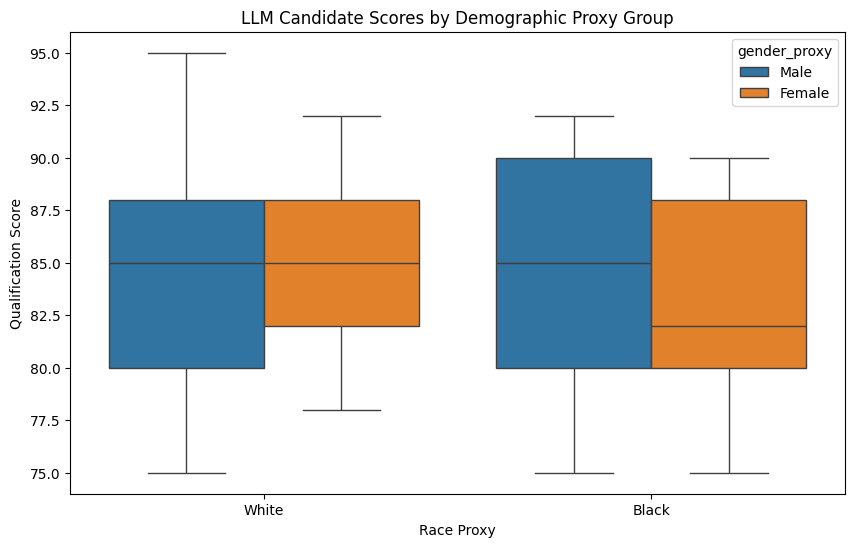

In [5]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="race_proxy",
    y="score",
    hue="gender_proxy"
)

plt.title("LLM Candidate Scores by Demographic Proxy Group")
plt.xlabel("Race Proxy")
plt.ylabel("Qualification Score")

plt.show()


The boxplots show that the score distributions for the four demographic proxy groups overlap meaning the model often produced similar scores across groups.

## 4. T-Test Interpretation

### Black Female vs. White Female Comparison
To evaluate whether the observed score differences between demographic proxy groups were likely caused by random variation, I performed an independent two-sample t-test.

A t-test compares the average values of two groups while also accounting for the variability within each group. In this experiment, the test compares:

- Black female-associated candidate scores
vs
- White female-associated candidate scores

The null hypothesis assumes that there is no real difference between the two groups and that any observed difference is simply due to randomness in the model’s outputs.

In [6]:
black_female_scores = df[
    (df["race_proxy"] == "Black") &
    (df["gender_proxy"] == "Female")
]["score"]

white_female_scores = df[
    (df["race_proxy"] == "White") &
    (df["gender_proxy"] == "Female")
]["score"]

t_stat, p_value = ttest_ind(
    black_female_scores,
    white_female_scores
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -3.3474091019375716
P-value: 0.0009761840179706442


The t-test produced:

- t-statistic ≈ -3.35
- p-value ≈ 0.001

Because the p-value is substantially below the common significance threshold of `0.05`, the observed difference is unlikely to be explained entirely by random variation within this experiment.

The negative t-statistic indicates that Black female-associated names received lower scores on average than White female-associated names.

Although the score difference itself seems to be normal at first, the repeated sampling setup of 100 evaluations per group allows the model to detect whether the pattern appears consistently across many independent generations rather than only in isolated outputs.

This result does not prove intentional bias or real-world discrimination. But it does suggest that under repeated controlled prompting, statistically measurable score differences did emerge between these two demographic proxy groups despite identical qualifications.

### Black Female vs. Black Male Comparison

Because the average scores for Black female-associated names and Black male-associated names appear different, I also compare these two groups directly using the t-test.

In [8]:
black_female_scores = df[
    (df["race_proxy"] == "Black") &
    (df["gender_proxy"] == "Female")
]["score"]

black_male_scores = df[
    (df["race_proxy"] == "Black") &
    (df["gender_proxy"] == "Male")
]["score"]

t_stat, p_value = ttest_ind(
    black_female_scores,
    black_male_scores
)


print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -3.4168608724262293
P-value: 0.000768742674250291



The t-test produced:

- t-statistic ≈ -3.42
- p-value ≈ 0.0008

Because the p-value is substantially below the common significance threshold of `0.05`, the observed score difference between these two groups is unlikely to be explained entirely by random variation within this experiment.

The negative t-statistic indicates that Black female-associated names received lower scores on average than Black male-associated names.

This comparison is particularly important because both groups share the same race-associated proxy meaning the primary difference between the two groups is the gender-associated proxy contained in the candidate names.

Although the magnitude of the score difference remains relatively modest overall the repeated sampling setup of 100 evaluations per group allows the analysis to determine whether the pattern appears consistently across many independent generations rather than only in isolated outputs.

# 5. Regression Modeling

While the earlier t-tests compared differences between specific groups individually, linear regression allows me to examine how multiple demographic proxy variables relate to candidate scores simultaneously.

Linear regression models the relationship between one target variable and one or more predictor variables. In this project:

- the target variable is the LLM-generated qualification score
- the predictor variables are demographic proxy indicators derived from candidate names

The model estimates how each variable shifts the predicted score while holding the other variables constant.

The regression model used in this analysis predicts qualification score using:

- race proxy
- gender proxy

The regression allows the effects of multiple variables to be interpreted simultaneously which makes it useful for estimating the independent relationship between demographic proxy variables and LLM-generated scores.

### Feature Engineering

Because regression models require numeric inputs, the demographic proxy variables are converted into binary indicator variables.

To represent these categories numerically:

- `is_black = 1` for Black-associated names and `0` otherwise
- `is_male = 1` for male-associated names and `0` otherwise

White female-associated names therefore become the baseline reference group because both indicator variables equal `0` for that category.

In [10]:
df["is_black"] = (
    df["race_proxy"] == "Black"
).astype(int)

df["is_male"] = (
    df["gender_proxy"] == "Male"
).astype(int)

The regression model uses:

- demographic proxy indicator variables as predictors (`X`)
- LLM-generated qualification score as the target variable (`y`)

In [11]:
X = df[["is_black", "is_male"]]
y = df["score"]

The linear regression model is fit using the demographic proxy variables to estimate their relationship with qualification score.

In [12]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
print("Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

Intercept: 84.3575


,Feature,Coefficient
0,is_black,-0.375
1,is_male,0.605


# 6. Regression Interpretation

The regression model estimates how each demographic proxy variable relates to qualification score while holding the other variables constant.

The intercept of approximately `84.36` represents the predicted score for the baseline reference group. Because both indicator variables equal `0` for White female-associated names, this value corresponds to the model’s predicted score for that group.

The coefficient for `is_black` is approximately `-0.375`.

This indicates that when holding gender constant, Black-associated names received scores about `0.38` points lower on average than White-associated names.

The coefficient for `is_male` is approximately `0.605`.

This indicates that, holding race constant, male-associated names received scores about `0.61` points higher on average than female-associated names.

These coefficients are obvoiously quite small in their magnitude. This suggests that while statistically measurable differences appeared in the experiment, the overall effect sizes were modest relative to the score scale.

### Regression-Predicted Scores by Demographic Proxy Group

Using the fitted regression model, predicted qualification scores can be generated for each demographic proxy group.

These predictions represent the scores estimated directly by the linear regression model after accounting for the demographic proxy variables included in the analysis.

This allows the model’s estimated group-level scoring patterns to be visualized more clearly (easier to see the difference).

In [25]:
predicted_scores = pd.DataFrame({
    "Group": [
        "White Female",
        "Black Female",
        "White Male",
        "Black Male"
    ],
    "Predicted Score": [
        model.predict([[0, 0]])[0],
        model.predict([[1, 0]])[0],
        model.predict([[0, 1]])[0],
        model.predict([[1, 1]])[0]
    ]
})

predicted_scores

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Group,Predicted Score
0,White Female,84.3575
1,Black Female,83.9825
2,White Male,84.9625
3,Black Male,84.5875


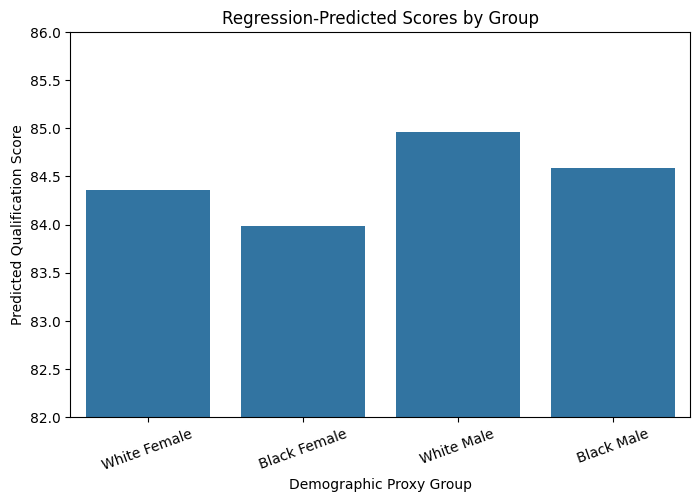

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=predicted_scores,
    x="Group",
    y="Predicted Score"
)

plt.ylim(82, 86)

plt.title("Regression-Predicted Scores by Group")
plt.xlabel("Demographic Proxy Group")
plt.ylabel("Predicted Qualification Score")

plt.xticks(rotation=20)

plt.show()

##### Predicted Score Interpretation

The regression model predicts the highest average score for White male-associated names and the lowest average score for Black female-associated names.

The predicted scores for all four groups remain relatively close overall indicating that the estimated effects are very modest in magnitude.

However the visualization still reflects a consistent directional pattern in which:

- male-associated names receive slightly higher predicted scores
- Black-associated names receive slightly lower predicted scores

It is interesting to see that even though it is on such a small scale, why is there any difference at all?

### Predicted Score Difference Relative to Baseline Group

To make the regression effects easier to interpret, the predicted scores can also be expressed relative to a baseline reference group.

In this visualization:

- White female-associated names are treated as the baseline group
- all other groups are shown as deviations from that baseline

Positive values indicate groups predicted to receive slightly higher scores than the baseline, while negative values indicate groups predicted to receive slightly lower scores.

In [27]:
baseline = predicted_scores[
    predicted_scores["Group"] == "White Female"
]["Predicted Score"].iloc[0]

predicted_scores["Difference from White Female"] = (
    predicted_scores["Predicted Score"] - baseline
)

predicted_scores

,Group,Predicted Score,Difference from White Female
0,White Female,84.3575,0.000
1,Black Female,83.9825,-0.375
2,White Male,84.9625,0.605
3,Black Male,84.5875,0.230


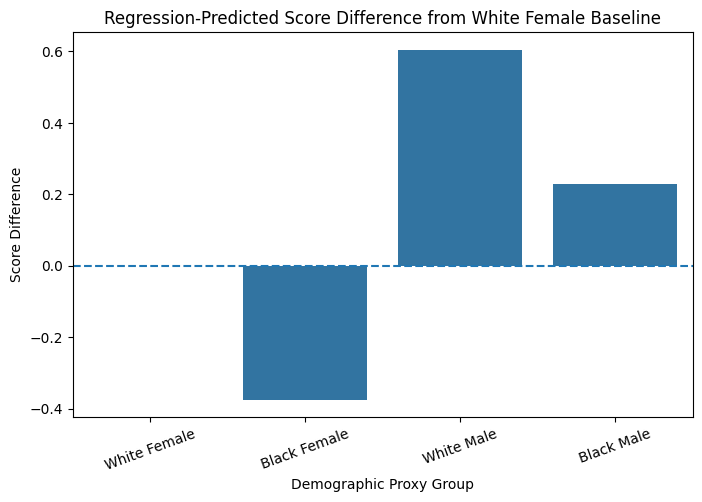

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=predicted_scores,
    x="Group",
    y="Difference from White Female"
)

plt.axhline(0, linestyle="--")

plt.title("Regression-Predicted Score Difference from White Female Baseline")
plt.xlabel("Demographic Proxy Group")
plt.ylabel("Score Difference")

plt.xticks(rotation=20)

plt.show()

##### Baseline Difference Interpretation

Relative to the White female baseline group:

- Black female-associated names were predicted to receive slightly lower scores
- White male-associated names were predicted to receive the largest positive score difference
- Black male-associated names remained above the baseline overall, although the positive gender-associated effect was partially offset by the negative race-associated effect estimated by the model

This visualization highlights how the regression model combines the estimated effects of multiple demographic proxy variables simultaneously.

Although the differences remain relatively small on the overall scoring scale, the model still does identify shifts associated with the demographic proxy indicators included in the experiment.

# Final Conclusion

## Revisiting the Original Research Question

The original goal of this project was to investigate whether an LLM would assign different qualification scores to candidates with identical qualifications but different demographic proxy names.

To test this question, all candidate qualifications were intentionally held constant while only the candidate names changed. The names were selected to act as demographic proxies for race and gender.

Across 400 total evaluations generated by Gemini 2.5 Flash, the analysis showed small but measurable differences in the scores assigned to different demographic proxy groups.

In particular:

- Black female-associated names received the lowest average scores overall
- White male-associated names received the highest predicted scores overall
- Male-associated names generally received slightly higher scores than female-associated names
- Black-associated names generally received slightly lower scores than White-associated names

The statistical testing and regression modeling both identified consistent directional differences across repeated evaluations.

## Summary of Statistical Findings

Several forms of analysis were used throughout this project:

### Descriptive Statistics
Average scores and score distributions were compared across demographic proxy groups.

### Visualization
Boxplots and regression-based visualizations were used to observe trends and overlaps between groups.

### T-Tests
Independent two-sample t-tests were used to evaluate whether observed differences between groups were likely due to random variation alone.

The comparison between Black female-associated names and White female-associated names produced:

- a statistically significant p-value
- evidence that the observed score differences were unlikely to occur entirely by chance within this experiment

### Linear Regression
Linear regression was used to estimate the independent relationship between demographic proxy variables and qualification score.

The regression coefficients suggested:

- a small negative relationship associated with Black-associated names
- a small positive relationship associated with male-associated names

Although the estimated effects were modest in magnitude, the patterns remained relatively consistent across repeated generations.

## Do These Results Prove Bias?

The results suggest that demographic proxy names may influence LLM-generated candidate evaluations under controlled prompting conditions.

However, this project does **not** prove intentional bias, discrimination, or malicious behavior by the model.

Instead, the findings demonstrate that: Measurable scoring differences can emerge even when qualifications remain identical and only demographic proxy information changes.

The observed score differences were relatively small overall and the score distributions between groups still overlapped substantially.

This means the experiment detected statistical patterns rather than extreme or universally consistent discrimination.

## Possible Explanations for the Results

There are several possible explanations for why these score differences appeared.

One possibility is that the model has learned subtle associations from large-scale internet training data. Because LLMs are trained on massive collections of human-written text, historical societal patterns and stereotypes may indirectly influence generated outputs.

It is therefore difficult to determine how much of the observed variation is caused by:
- demographic proxy effects
- normal randomness
- prompt sensitivity
- or interactions between multiple factors simultaneously

## Limitations and Flaws of the Study

This project contains several important limitations that should be acknowledged.

### Limited Candidate Complexity

The experiment used only a small number of candidate profiles with intentionally simplified information. Real hiring evaluations involve significantly more context, including:

- detailed resumes
- work experience
- interview performance
- technical assessments
- educational background
- and interpersonal factors

### Reliance on Name-Based Proxies

Race and gender were not directly measured. Instead, demographic assumptions were inferred from names commonly associated with particular groups. This creates ambiguity because names do not perfectly represent real demographic identity.

### Prompt Engineering Sensitivity

The wording, structure, and tone of the prompt may influence model behavior substantially.

Small changes in phrasing:
- score distributions
- variability
- or demographic patterns

As a result, the findings may not generalize across all prompt designs.

### Single Model and Configuration

The experiment only tested:

- Gemini 2.5 Flash
- one temperature setting
- one prompting structure

Different models or configurations may behave differently.

### Limited Feature Space

The regression model only included two demographic proxy variables:

- race proxy
- gender proxy

This creates a very simplified statistical model that cannot fully capture the complexity of real-world hiring systems.

### Artificial Experimental Environment

This was a controlled simulation rather than a real hiring process.

Real recruiters use:
- multiple evaluation stages
- human judgment
- team discussions
- organizational constraints
- and additional contextual information

Therefore, these results should not be interpreted as direct evidence about real hiring outcomes. It is more focused on the LLM itself. The hiring process simulation is just used as a way to test it.

## Final Reflection

Despite its limitations, this project demonstrates how statistical analysis and repeated experimentation can be used to systematically evaluate patterns in generative AI systems.

By combining:
- repeated prompting
- visualization
- statistical significance testing
- and regression modeling

the study was able to identify measurable differences in LLM-generated candidate evaluations associated with demographic proxy names.

This project highlights the importance of critically evaluating AI systems rather than treating model outputs as fully objective or neutral.

As LLMs become more integrated into decision-making, understanding how models behave under controlled conditions becomes an important part of responsible AI analysis and development.